<div class="alert alert-info" role="alert" style="padding:20px; margin-bottom:16px;">
  <div style="text-align:center;">
    <h1 style="margin:0;">Exploratory Data Analysis</h1>
    <div style="font-size:18px; margin-top:4px;">Amazing International Airlines Inc.</div>
    <div style="font-size:18px; margin-top:4px;">Clustering - Value Based</div>
    <hr style="margin:12px auto; width:220px;">
    <div style="font-size:14px; color:#6c757d;">Group 92 • Notebook • 2025/2026</div>
  </div>
</div>


| Student Name | Student ID | Email |
| :--- | :--- | :--- |
| **Mehmet Karaca** | 20250344 | 20250344@novaims.unl.pt |
| **Duarte Gomes** | 20250017 | 20250017@novaims.unl.pt |
| **Esra Salhi** | 20250537 | 20250537@novaims.unl.pt |

## Table of Contents

1. [Introduction](#introduction)
    - 1.1. [Importing Libraries](#importing-libraries)
    - 1.2. [Loading and Reading Data](#loading-and-reading-data)
    - 1.3. [Brief Preliminary Analysis](#brief-preliminary-analysis)
2. [Clustering](#clustering)
    - 2.1. [Value based Clustering](#value-based-clustering)
    - 2.2. [Demographic Clustering](#demographic-clustering)
3. [Merging Clusters](#merging-clusters)
    - 3.1. [Merging Clusters](#merging-clusters-1)
    - 3.2. [Interpretation of Merged Clusters](#interpretation)


# 1 Introduction <a id="introduction"></a>

In this project, we act as consultants for **Amazing International Airlines Inc. (AIAI)** to develop a data-driven customer segmentation strategy. The goal is to identify distinct customer groups to enable personalized marketing and service improvements.

## Scope of Analysis: A Dual-Perspective Approach
To create a segmentation framework that is both **actionable** and **interpretable** for the business stakeholders, we have strategically focused on two primary dimensions:

1.  **Value-based Segmentation:** Grouping customers based on their economic contribution (CLV, Income, Points). This answers the question: *"What is the customer worth?"*
2.  **Demographic Segmentation:** Categorizing customers by personal attributes (Age, Education, Location). This answers the question: *"Who is the customer?"*

*Note on Behavioral Data:*
While behavioral data (e.g., flight frequency) was available, we prioritized a **Value × Demographic** matrix for this strategic phase. Preliminary analysis suggested that adding a third dimension significantly increased model complexity and reduced the clarity of the resulting clusters ("Curse of Dimensionality"), making it harder to derive clear-cut marketing personas. By focusing on these two robust pillars, we ensure the final segments are distinct and operationally viable.


## 1.1. Importing Libraries <a id="importing-libraries"></a>


In [66]:
# Imports
import os
import math
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.lines as Line2D
import matplotlib as mpl
import seaborn as sns
import plotly.express as px
from cycler import cycler
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.base import clone
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neighbors import NearestNeighbors

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, MeanShift, estimate_bandwidth
from sklearn.mixture import GaussianMixture
from minisom import MiniSom

from sklearn.metrics import silhouette_score, davies_bouldin_score
from collections import Counter


In [67]:
import warnings

# Suppress FutureWarnings (covers the pandas 3.0 CoW warnings)
warnings.simplefilter(action='ignore', category=FutureWarning)

## 1.2. Loading and Reading Data <a id="loading-and-reading-data"></a>

In [68]:
# directory with raw CSV files
data_dir = Path("../data/cleanAndFeatureEngineered")

# list all CSV files
csv_files = list(data_dir.glob("*.csv"))
print(f"Found CSV files: {[f.name for f in csv_files]}")


Found CSV files: ['DM_AIAI_FlightsDB_Cleaned_Featured.csv', 'DM_AIAI_CustomerDB_Cleaned_Featured.csv']


In [69]:
# specify the files we want to load

customers_file = data_dir / "DM_AIAI_CustomerDB_Cleaned_Featured.csv"
flights_file   = data_dir / "DM_AIAI_FlightsDB_Cleaned_Featured.csv"

# load them with pandas
customers = pd.read_csv(customers_file)
flights   = pd.read_csv(flights_file)

print("Customers shape:", customers.shape)
print("Flights shape:", flights.shape)

Customers shape: (16375, 53)
Flights shape: (596664, 11)


## 1.3. Brief Preliminary Analysis <a id="brief-preliminary-analysis"></a>

In [70]:
# Put Loyalty# as index
customers.set_index('Loyalty#', inplace=True)
customers.columns


Index(['First Name', 'Last Name', 'Customer Name', 'Country',
       'Province or State', 'City', 'Latitude', 'Longitude', 'Postal code',
       'Gender', 'Education', 'Location Code', 'Income', 'Marital Status',
       'LoyaltyStatus', 'EnrollmentDateOpening', 'CancellationDate',
       'Customer Lifetime Value', 'EnrollmentType', 'IsActive',
       'CustomerTenureDays', 'total_flights', 'total_flights_with_companions',
       'total_distance', 'total_points_accumulated', 'total_points_redeemed',
       'total_cost_redeemed', 'average_distance_per_flight',
       'points_redemption_ratio', 'companion_flight_ratio',
       'LoyaltyStatus_Nova', 'LoyaltyStatus_Star', 'EnrollmentType_Standard',
       'Gender_male', 'Education_College', 'Education_Doctor',
       'Education_High School or Below', 'Education_Master',
       'Marital Status_Married', 'Marital Status_Single',
       'Province or State_British Columbia', 'Province or State_Manitoba',
       'Province or State_New Brunswick',

In [71]:
customers.describe(include='number')

,Latitude,Longitude,Income,Customer Lifetime Value,IsActive,CustomerTenureDays,total_flights,total_flights_with_companions,total_distance,total_points_accumulated,...,Province or State_New Brunswick,Province or State_Newfoundland,Province or State_Nova Scotia,Province or State_Ontario,Province or State_Prince Edward Island,Province or State_Quebec,Province or State_Saskatchewan,Province or State_Yukon,Location Code_Suburban,Location Code_Urban
count,1.637500e+04,1.637500e+04,1.637500e+04,1.637500e+04,16375.000000,1.637500e+04,1.637500e+04,1.637500e+04,1.637500e+04,1.637500e+04,...,1.637500e+04,1.637500e+04,1.637500e+04,1.637500e+04,1.637500e+04,1.637500e+04,1.637500e+04,1.637500e+04,16375.000000,1.637500e+04
mean,-3.888350e-15,2.681621e-16,-1.388542e-17,8.331249e-17,0.874931,-1.238839e-16,9.633007e-17,-1.598992e-16,-1.863683e-16,2.625211e-17,...,6.508788e-18,2.082812e-17,1.006693e-16,1.024049e-16,3.037435e-17,9.112304e-17,5.207031e-18,7.550195e-17,0.000000,1.735677e-18
std,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00,0.330807,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00,...,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00,1.000031,1.000031e+00
min,-1.266925e+00,-1.942818e+00,-1.243243e+00,-8.893668e-01,0.000000,-1.489489e+00,-2.348401e+00,-1.532043e+00,-1.786988e+00,-1.786934e+00,...,-1.985411e-01,-1.237537e-01,-1.821763e-01,-6.905228e-01,-6.361482e-02,-4.939811e-01,-1.564032e-01,-8.071839e-02,-0.716227,-6.957365e-01
25%,-8.900536e-01,-1.276641e+00,-1.243243e+00,-5.851120e-01,1.000000,-9.714138e-01,-5.664426e-01,-8.118356e-01,-8.402688e-01,-8.403008e-01,...,-1.985411e-01,-1.237537e-01,-1.821763e-01,-6.905228e-01,-6.361482e-02,-4.939811e-01,-1.564032e-01,-8.071839e-02,-0.716227,-6.957365e-01
50%,-3.285937e-01,5.599171e-01,-1.188661e-01,-3.217508e-01,1.000000,-9.716237e-02,1.911105e-01,4.341034e-02,2.687935e-01,2.688672e-01,...,-1.985411e-01,-1.237537e-01,-1.821763e-01,-6.905228e-01,-6.361482e-02,-4.939811e-01,-1.564032e-01,-8.071839e-02,-0.716227,-6.957365e-01
75%,6.375646e-01,7.751104e-01,8.125391e-01,1.395840e-01,1.000000,8.769265e-01,7.854892e-01,7.186045e-01,7.650067e-01,7.650795e-01,...,-1.985411e-01,-1.237537e-01,-1.821763e-01,1.448178e+00,-6.361482e-02,-4.939811e-01,-1.564032e-01,-8.071839e-02,1.396205,1.437326e+00
max,4.096615e+00,1.758859e+00,2.051974e+00,1.101364e+01,1.000000,1.837524e+00,2.644027e+00,3.824498e+00,2.605733e+00,2.605996e+00,...,5.036741e+00,8.080566e+00,5.489187e+00,1.448178e+00,1.571961e+01,2.024369e+00,6.393731e+00,1.238875e+01,1.396205,1.437326e+00


# 2. Clustering

For the Clustering phase, we will proceed sequentially:
1.  **Value-Based Perspective:** Identifying high-value vs. low-value tiers.
2.  **Demographic Perspective:** Identifying life-stage and location-based profiles.

This separation allows us to optimize the clusters for each perspective independently before merging them into a unified framework.


In [72]:
# Cell 3: Helper functions from Labs 09-12

def get_ss(df, feats):
    """
    Calculate the sum of squares (SS) for the given DataFrame.
    The sum of squares is computed as the sum of the variances of each column
    multiplied by the number of non-NA/null observations minus one.
    
    Parameters:
    df (pandas.DataFrame): The input DataFrame for which the sum of squares is to be calculated.
    feats (list of str): A list of feature column names to be used in the calculation.
    
    Returns:
    float: The sum of squares of the DataFrame.
    """
    df_ = df[feats]
    ss = np.sum(df_.var() * (df_.count() - 1))
    return ss


def get_ssb(df, feats, label_col):
    """
    Calculate the between-group sum of squares (SSB) for the given DataFrame.
    The between-group sum of squares is computed as the sum of the squared differences
    between the mean of each group and the overall mean, weighted by the number of observations
    in each group.
    
    Parameters:
    df (pandas.DataFrame): The input DataFrame containing the data.
    feats (list of str): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column in the DataFrame that contains the group labels.
    
    Returns:
    float: The between-group sum of squares of the DataFrame.
    """
    ssb_i = 0
    for i in np.unique(df[label_col]):
        df_ = df.loc[:, feats]
        X_ = df_.values
        X_k = df_.loc[df[label_col] == i].values
        
        ssb_i += (X_k.shape[0] * (np.square(X_k.mean(axis=0) - X_.mean(axis=0))))
    
    ssb = np.sum(ssb_i)
    return ssb


def get_ssw(df, feats, label_col):
    """
    Calculate the sum of squared within-cluster distances (SSW) for a given DataFrame.
    
    Parameters:
    df (pandas.DataFrame): The input DataFrame containing the data.
    feats (list of str): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column containing cluster labels.
    
    Returns:
    float: The sum of squared within-cluster distances (SSW).
    """
    feats_label = feats + [label_col]
    df_k = df[feats_label].groupby(by=label_col).apply(
        lambda col: get_ss(col, feats),
        include_groups=False
    )
    return df_k.sum()


def get_rsq(df, feats, label_col):
    """
    Calculate the R-squared value for a given DataFrame and features.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame containing the data.
    feats (list): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column containing the labels or cluster assignments.
    
    Returns:
    float: The R-squared value, representing the proportion of variance explained by the clustering.
    """
    df_sst_ = get_ss(df, feats)  # get total sum of squares
    df_ssw_ = get_ssw(df, feats, label_col)  # get ss within
    df_ssb_ = df_sst_ - df_ssw_  # get ss between
    # r2 = ssb/sst
    return (df_ssb_ / df_sst_)


def get_r2_scores(df, feats, clusterer, min_k=2, max_k=11):
    """
    Loop over different values of k. To be used with sklearn clusterers.
    """
    r2_clust = {}
    for n in range(min_k, max_k):
        clust = clone(clusterer).set_params(n_clusters=n)
        labels = clust.fit_predict(df)
        df_concat = pd.concat([df,
                               pd.Series(labels, name='labels', index=df.index)], axis=1)
        r2_clust[n] = get_rsq(df_concat, feats, 'labels')
    return r2_clust

In [73]:
# Cell 5: Define feature perspectives

# demographic features selection (only categorical features encoded as dummies)
demographic_features = [
    'Location Code_Suburban',
    'Location Code_Urban',
    'Gender_male',
    'Education_College',
    'Education_High School or Below',
    'Education_Master',
    'Education_Doctor',
    'Marital Status_Married',
    'Marital Status_Single',
]

# Value based features selection
value_based_features = [
    'Customer Lifetime Value',
    'Income',
    'total_points_accumulated',
    'total_cost_redeemed']

# Combined metric features (for final analysis)
metric_features = demographic_features + value_based_features

print("Demographic features:", demographic_features)
print("Value based features:", value_based_features)
print("Total metric features:", len(metric_features))


Demographic features: ['Location Code_Suburban', 'Location Code_Urban', 'Gender_male', 'Education_College', 'Education_High School or Below', 'Education_Master', 'Education_Doctor', 'Marital Status_Married', 'Marital Status_Single']
Value based features: ['Customer Lifetime Value', 'Income', 'total_points_accumulated', 'total_cost_redeemed']
Total metric features: 13


## 2.1 Value based Clustering

In this Section we prepare our data for Value Based Clustering.
We have to decide, which features we will use for Clustering from Value Based Perspective.
We selected the features based on domain knowledge and our understanding of the business.
We will use the following features for Clustering from Value Based Perspective:

In [74]:
# Show the selected featurescustomers[preference_features].head()
customers[value_based_features].head()

# Print number of metric features   
print ("Number of metric features:", len(value_based_features))

# check if metric or not 

for feature in value_based_features:
    if pd.api.types.is_numeric_dtype(customers[feature]):
        print(f"{feature}: Metric")
    else:
        print(f"{feature}: Not Metric")


# Create the pandas dataframe df_value_based
df_value_based = pd.DataFrame(customers[value_based_features])

df_value_based.head()

Number of metric features: 4
Customer Lifetime Value: Metric
Income: Metric
total_points_accumulated: Metric
total_cost_redeemed: Metric


,Customer Lifetime Value,Income,total_points_accumulated,total_cost_redeemed
Loyalty#,,,,
480934,-0.605614,1.068659,1.338311,0.576033
549612,-0.605545,-1.243243,0.843514,1.584071
429460,-0.605524,-1.243243,-0.317841,-0.369294
608370,-0.605524,-1.243243,0.592203,0.896561
530508,-0.605080,1.981146,0.488700,-0.987124


Before starting with the first Clustering Method, we will remove highly correlated features from the dataset. Highly correlated features can negatively impact the performance of clustering algorithms (e.g., KMeans). We will use a correlation threshold of 0.8 to identify and remove highly correlated features.

In [ ]:
# Check for correlation inside the value based features
plt.figure(figsize=(12, 8))
correlation_matrix = df_value_based.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix for Value Based Features")
plt.show()

threshold = 0.8
unstacked = correlation_matrix.unstack()
high_corr = unstacked[(unstacked.abs() > threshold) & (unstacked != 1.0)].drop_duplicates()

print(f"Pairs with correlation > {threshold} or < -{threshold}:")
print(high_corr)

We will do K-Means++ Clustering and compare it with Hierarchical Clustering

In [ ]:
# --- Comprehensive Clustering Evaluation with All Metrics ---

def evaluate_clustering_methods(data, feats, min_k=2, max_k=11):
    """
    Evaluates multiple clustering methods and calculates:
    - R2 Score
    - Davies-Bouldin Index (DBI)
    - Silhouette Score
    - Inertia (for KMeans-based methods)
    
    Returns a dictionary with DataFrames for each method.
    """
    
    X = data.values if isinstance(data, pd.DataFrame) else data
    
    # Calculate Total Sum of Squares (SST) once for R2 calculation
    centroid = X.mean(axis=0)
    sst = np.sum((X - centroid) ** 2)
    
    # Initialize results dictionary
    results_by_method = {}
    
    # --- K-MEANS ---
    print("Evaluating K-Means...")
    kmeans_results = []
    kmeans_clusterer = KMeans(init='k-means++', n_init=20, random_state=42)
    
    for k in range(min_k, max_k):
        kmeans = clone(kmeans_clusterer).set_params(n_clusters=k)
        labels = kmeans.fit_predict(X)
        
        # Calculate metrics
        ssw = kmeans.inertia_
        r2 = 1 - (ssw / sst)
        dbi = davies_bouldin_score(X, labels)
        sil = silhouette_score(X, labels)
        
        kmeans_results.append({
            'K': k,
            'R2_Score': r2,
            'Davies_Bouldin': dbi,
            'Silhouette': sil,
            'Inertia': ssw
        })
    
    df_kmeans = pd.DataFrame(kmeans_results)
    df_kmeans.loc[:, 'R2_Pct_Change'] = df_kmeans['R2_Score'].pct_change() * 100
    df_kmeans.loc[:, 'DBI_Pct_Change'] = df_kmeans['Davies_Bouldin'].pct_change() * 100
    df_kmeans.loc[:, 'Sil_Pct_Change'] = df_kmeans['Silhouette'].pct_change() * 100
    df_kmeans.loc[:, 'Inertia_Pct_Change'] = df_kmeans['Inertia'].pct_change() * 100
    
    results_by_method['kmeans'] = df_kmeans
    
    # --- HIERARCHICAL CLUSTERING (Various Linkages) ---
    hierarchical_clusterer = AgglomerativeClustering(metric='euclidean')
    
    for linkage_type in ['complete', 'average', 'single', 'ward']:
        print(f"Evaluating Hierarchical Clustering ({linkage_type})...")
        hc_results = []
        
        for k in range(min_k, max_k):
            hc = clone(hierarchical_clusterer).set_params(n_clusters=k, linkage=linkage_type)
            labels = hc.fit_predict(X)
            
            # Calculate metrics
            dbi = davies_bouldin_score(X, labels)
            sil = silhouette_score(X, labels)
            
            # Calculate R2 for hierarchical clustering
            df_concat = pd.concat([data, pd.Series(labels, name='labels', index=data.index)], axis=1)
            r2 = get_rsq(df_concat, feats, 'labels')
            
            # Hierarchical clustering doesn't have inertia, so we'll use None
            hc_results.append({
                'K': k,
                'R2_Score': r2,
                'Davies_Bouldin': dbi,
                'Silhouette': sil,
                'Inertia': np.nan  # Not applicable for hierarchical clustering
            })
        
        df_hc = pd.DataFrame(hc_results)
        df_hc.loc[:, 'R2_Pct_Change'] = df_hc['R2_Score'].pct_change() * 100
        df_hc.loc[:, 'DBI_Pct_Change'] = df_hc['Davies_Bouldin'].pct_change() * 100
        df_hc.loc[:, 'Sil_Pct_Change'] = df_hc['Silhouette'].pct_change() * 100
        df_hc.loc[:, 'Inertia_Pct_Change'] = df_hc['Inertia'].pct_change() * 100
        
        results_by_method[linkage_type] = df_hc
    
    return results_by_method

# --- EXECUTION ---
print("Starting comprehensive clustering evaluation...\n")
clustering_results = evaluate_clustering_methods(df_value_based, value_based_features, min_k=2, max_k=11)

# --- DISPLAY RESULTS FOR EACH METHOD ---
for method_name, df_method in clustering_results.items():
    print(f"\n{'='*80}")
    print(f"METHOD: {method_name.upper()}")
    print(f"{'='*80}")
    display(df_method.round(4))
    
    # Highlight best K for each metric
    print(f"\nBest configurations for {method_name}:")
    print(f"  - Highest R2: K={df_method.loc[df_method['R2_Score'].idxmax(), 'K']:.0f}")
    print(f"  - Lowest Davies-Bouldin: K={df_method.loc[df_method['Davies_Bouldin'].idxmin(), 'K']:.0f}")
    print(f"  - Highest Silhouette: K={df_method.loc[df_method['Silhouette'].idxmax(), 'K']:.0f}")

In [ ]:
# --- Visualization: 4 Subplots (One per Metric, All Methods) ---

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Prepare data for plotting
metrics_data = {
    'R2_Score': axes[0, 0],
    'Davies_Bouldin': axes[0, 1],
    'Silhouette': axes[1, 0],
    'Inertia': axes[1, 1]
}

metric_labels = {
    'R2_Score': 'R² Score (Higher is Better)',
    'Davies_Bouldin': 'Davies-Bouldin Index (Lower is Better)',
    'Silhouette': 'Silhouette Score (Higher is Better)',
    'Inertia': 'Inertia (Lower is Better)'
}

# Plot each metric
for metric_name, ax in metrics_data.items():
    for method_name, df_method in clustering_results.items():
        ax.plot(df_method['K'], df_method[metric_name], marker='o', label=method_name, linewidth=2)
    
    ax.set_title(metric_labels[metric_name], fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of Clusters (K)', fontsize=12)
    ax.set_ylabel(metric_name.replace('_', ' '), fontsize=12)
    ax.legend(title='Clustering Methods', title_fontsize=11, fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(2, 11))

    # Add horizontal threshold line for R² Score
    if metric_name == 'R2_Score':
        ax.axhline(y=0.5, color='r', linestyle='--', label='Threshold = 0.5')
        ax.legend(title='Clustering Methods', title_fontsize=11, fontsize=10)

plt.tight_layout()
plt.show()


Based on the evaluation metrics and visualizations, we decided to proceed with K-Means clustering using K = 4. This choice offers a balanced trade-off between cluster cohesion and separation.

In [75]:
# 1. Perform final clustering
k_best_value = 4

kmeans_value = KMeans(n_clusters=k_best_value, init='k-means++', n_init=20, random_state=42)

value_labels = kmeans_value.fit_predict(df_value_based)

customers['valuebased_cluster'] = value_labels

In [76]:
df_profile_value = df_value_based.copy()
df_profile_value['Cluster'] = value_labels

df_profile_value

,Customer Lifetime Value,Income,total_points_accumulated,total_cost_redeemed,Cluster
Loyalty#,,,,,
480934,-0.605614,1.068659,1.338311,0.576033,0
549612,-0.605545,-1.243243,0.843514,1.584071,3
429460,-0.605524,-1.243243,-0.317841,-0.369294,3
608370,-0.605524,-1.243243,0.592203,0.896561,3
530508,-0.605080,1.981146,0.488700,-0.987124,0
...,...,...,...,...,...
823768,7.874405,-1.243243,0.770479,-0.987124,2
680886,8.759826,1.337732,0.447844,0.902368,2
776187,9.683862,-1.243243,1.210686,0.828042,2


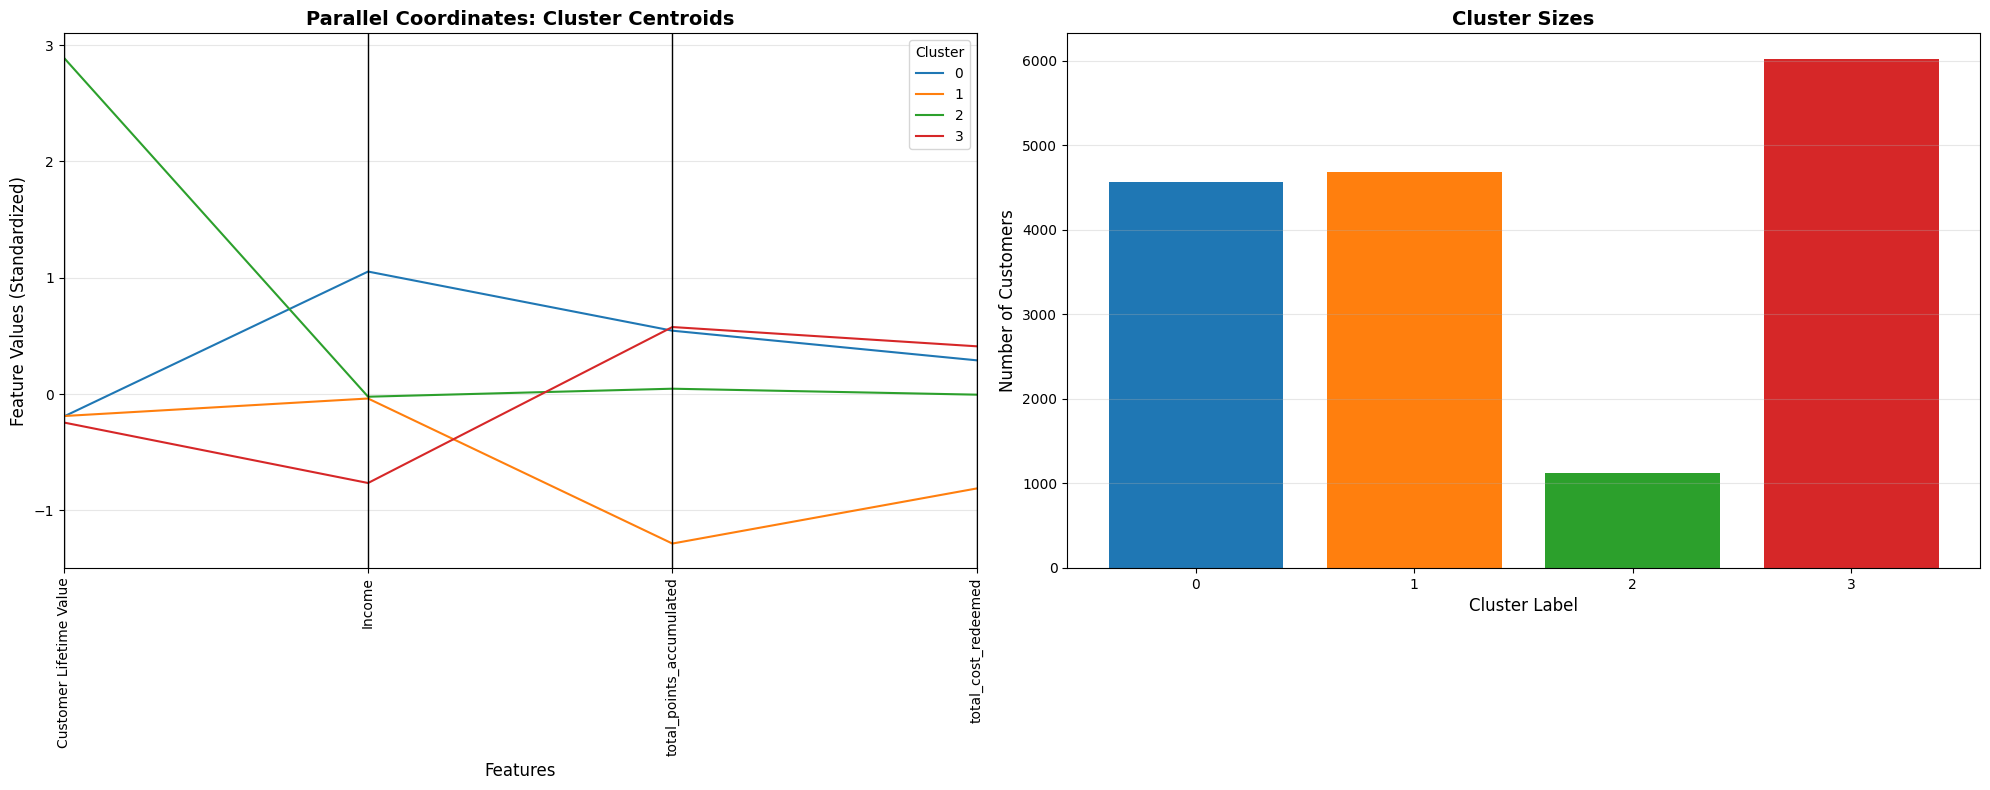

In [77]:
# Value based cluster profiling
df_profile_value = df_value_based.copy()
df_profile_value['Cluster'] = value_labels

# 3. Calculate Centroids (Average values per cluster)
df_centroids_value = df_profile_value.groupby('Cluster')[value_based_features].mean()

# --- Visualization 1: Parallel Coordinates & Cluster Sizes ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# LEFT PLOT: Parallel coordinates
# We use reset_index() so that 'Cluster' is a column for coloring
pd.plotting.parallel_coordinates(
    df_centroids_value.reset_index(),
    'Cluster',
    color=sns.color_palette('tab10', n_colors=k_best_value),
    ax=ax1
)
ax1.set_title('Parallel Coordinates: Cluster Centroids', fontsize=14, fontweight='bold')
ax1.set_ylabel('Feature Values (Standardized)', fontsize=12)
ax1.set_xlabel('Features', fontsize=12)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=90) # Rotate labels for readability
ax1.grid(True, alpha=0.3)
ax1.legend(title='Cluster', loc='best')

# RIGHT PLOT: Cluster sizes
cluster_sizes = df_profile_value['Cluster'].value_counts().sort_index()
colors = sns.color_palette('tab10', n_colors=k_best_value)

ax2.bar(cluster_sizes.index.astype(str), cluster_sizes.values, color=colors)
ax2.set_xlabel('Cluster Label', fontsize=12)
ax2.set_ylabel('Number of Customers', fontsize=12)
ax2.set_title('Cluster Sizes', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

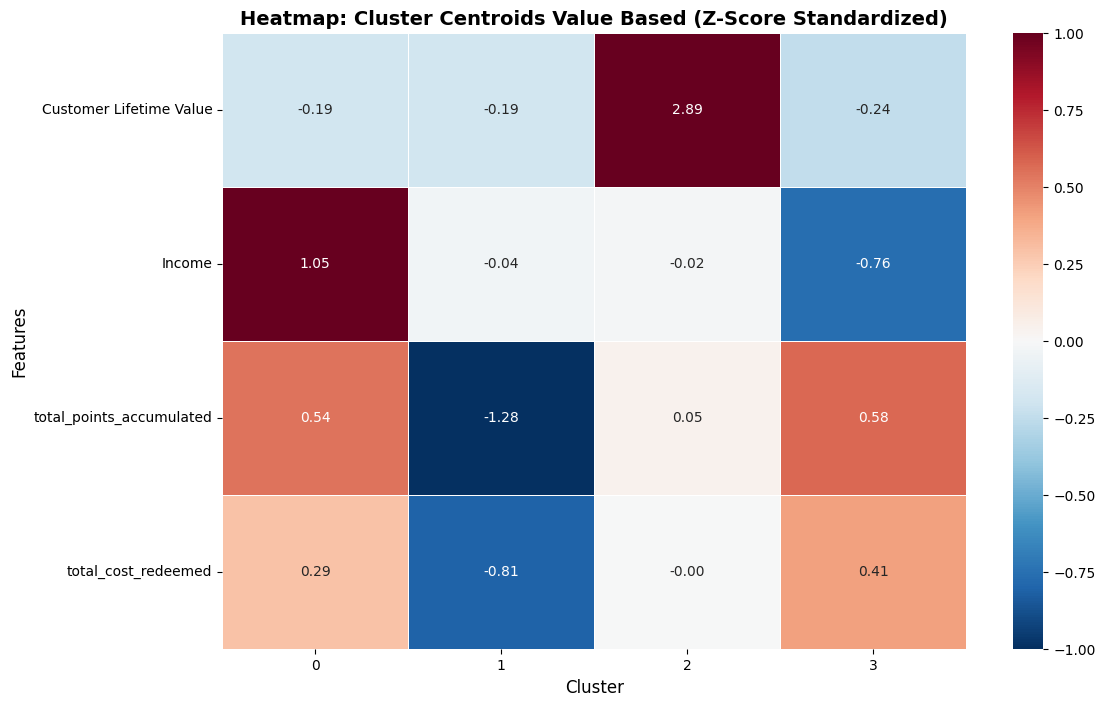

In [78]:
# --- Visualization 2: Heatmap of Centroids ---
plt.figure(figsize=(12, 8))

# Prepare data: Features as rows
df_plot = df_centroids_value.T

# Transpose (T) so that features are on the Y-axis
sns.heatmap(
    df_plot, 
    cmap='RdBu_r',  # Red-Blue colormap (good for deviations from the mean)
    center=0,       # Centered at 0 for standardized data
    annot=True,     # Show values
    fmt='.2f',      # 2 decimal places
    linewidths=.5,
    vmin=-1,        # Minimum at -1
    vmax=1          # Maximum at 1
)

plt.title('Heatmap: Cluster Centroids Value Based (Z-Score Standardized)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

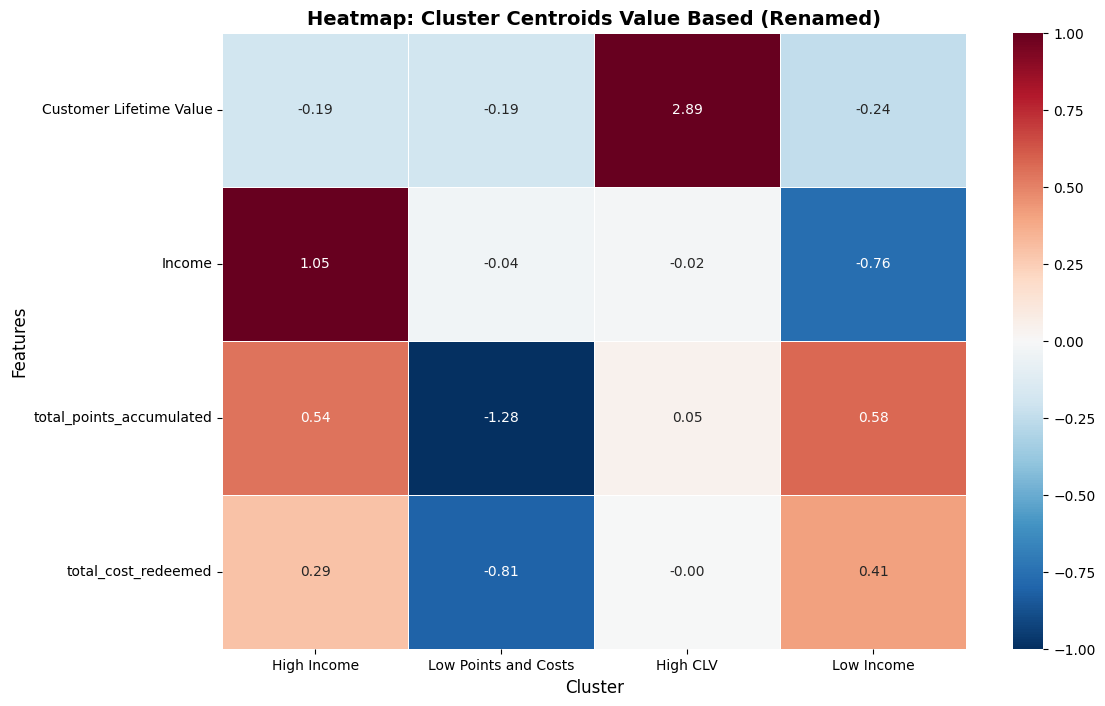

In [79]:
# --- Visualization 2: Heatmap of Centroids (Renamed) ---
plt.figure(figsize=(12, 8))

# Rename clusters
df_centroids_value_renamed = df_centroids_value.rename(index={
    0: 'High Income',
    1: 'Low Points and Costs',
    2: 'High CLV',
    3: 'Low Income'
})

# Prepare data: Features as rows
df_plot = df_centroids_value_renamed.T

# Transpose (T) so that features are on the Y-axis
sns.heatmap(
    df_plot, 
    cmap='RdBu_r',  # Red-Blue colormap (good for deviations from the mean)
    center=0,       # Centered at 0 for standardized data
    annot=True,     # Show values
    fmt='.2f',      # 2 decimal places
    linewidths=.5,
    vmin=-1,        # Minimum at -1
    vmax=1          # Maximum at 1
)

plt.title('Heatmap: Cluster Centroids Value Based (Renamed)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

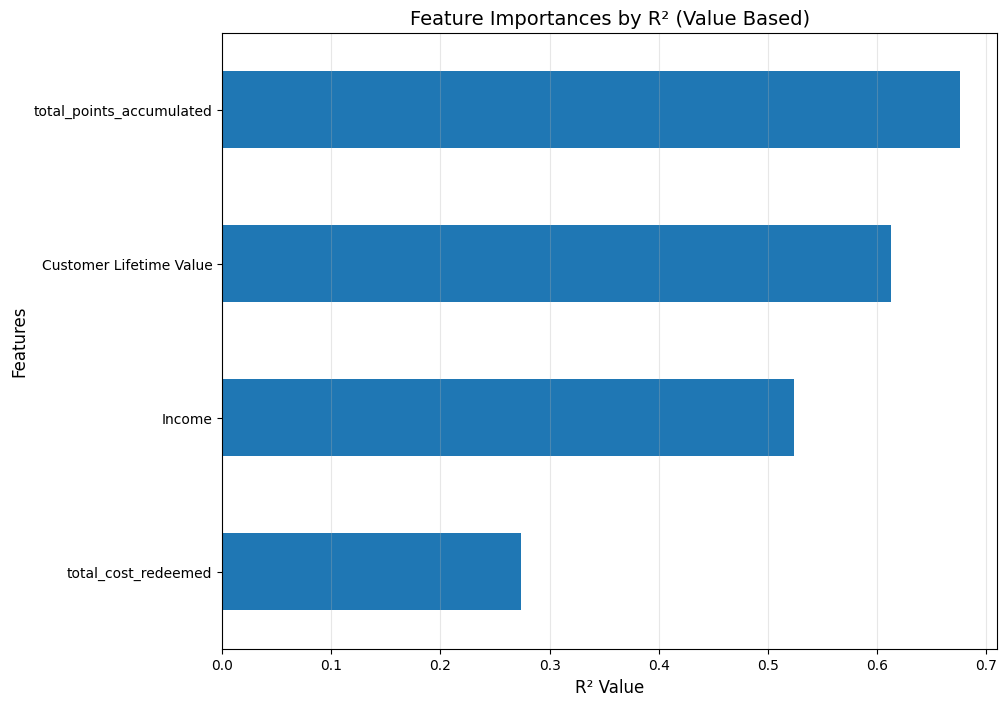

In [80]:
# Since 'r2_variables' is not defined, we calculate R2 for each feature individually
# using the existing 'get_rsq' function.
r2_data = {}
for feature in value_based_features:
    # get_rsq expects a list of features, hence [feature]
    r2_data[feature] = get_rsq(df_profile_value, [feature], 'Cluster')

r2_feats = pd.Series(r2_data)

# Plotting
r2_feats.sort_values().plot.barh(figsize=(10, 8))
plt.title("Feature Importances by R² (Value Based)", fontsize=14)
plt.xlabel("R² Value", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.show()

## 2.2 Demographic Clustering

In this section, we prepare our data for Demographic Clustering. We selected features based on domain knowledge to capture relevant demographic variations.

In [81]:
# Print number of metric features   
print ("Number of metric features:", len(demographic_features))

# check if metric or not 

for feature in demographic_features:
    if pd.api.types.is_numeric_dtype(customers[feature]):
        print(f"{feature}: Metric")
    else:
        print(f"{feature}: Not Metric")


# Create the pandas dataframe df_demographic
df_demographic = pd.DataFrame(customers[demographic_features])

df_demographic.head()

Number of metric features: 9
Location Code_Suburban: Metric
Location Code_Urban: Metric
Gender_male: Metric
Education_College: Metric
Education_High School or Below: Metric
Education_Master: Metric
Education_Doctor: Metric
Marital Status_Married: Metric
Marital Status_Single: Metric


,Location Code_Suburban,Location Code_Urban,Gender_male,Education_College,Education_High School or Below,Education_Master,Education_Doctor,Marital Status_Married,Marital Status_Single
Loyalty#,,,,,,,,,
480934,-0.716227,1.437326,-0.995430,-0.582545,-0.221224,-0.177105,-0.213677,0.846863,-0.605314
549612,-0.716227,-0.695737,1.004591,1.716605,-0.221224,-0.177105,-0.213677,-1.180828,-0.605314
429460,-0.716227,1.437326,1.004591,1.716605,-0.221224,-0.177105,-0.213677,-1.180828,1.652035
608370,1.396205,-0.695737,1.004591,1.716605,-0.221224,-0.177105,-0.213677,-1.180828,1.652035
530508,1.396205,-0.695737,1.004591,-0.582545,-0.221224,-0.177105,-0.213677,0.846863,-0.605314


Before starting with the first Clustering Method, we will remove highly correlated features from the dataset. Highly correlated features can negatively impact the performance of clustering algorithms (e.g., KMeans). We will use a correlation threshold of 0.8 to identify and remove highly correlated features.

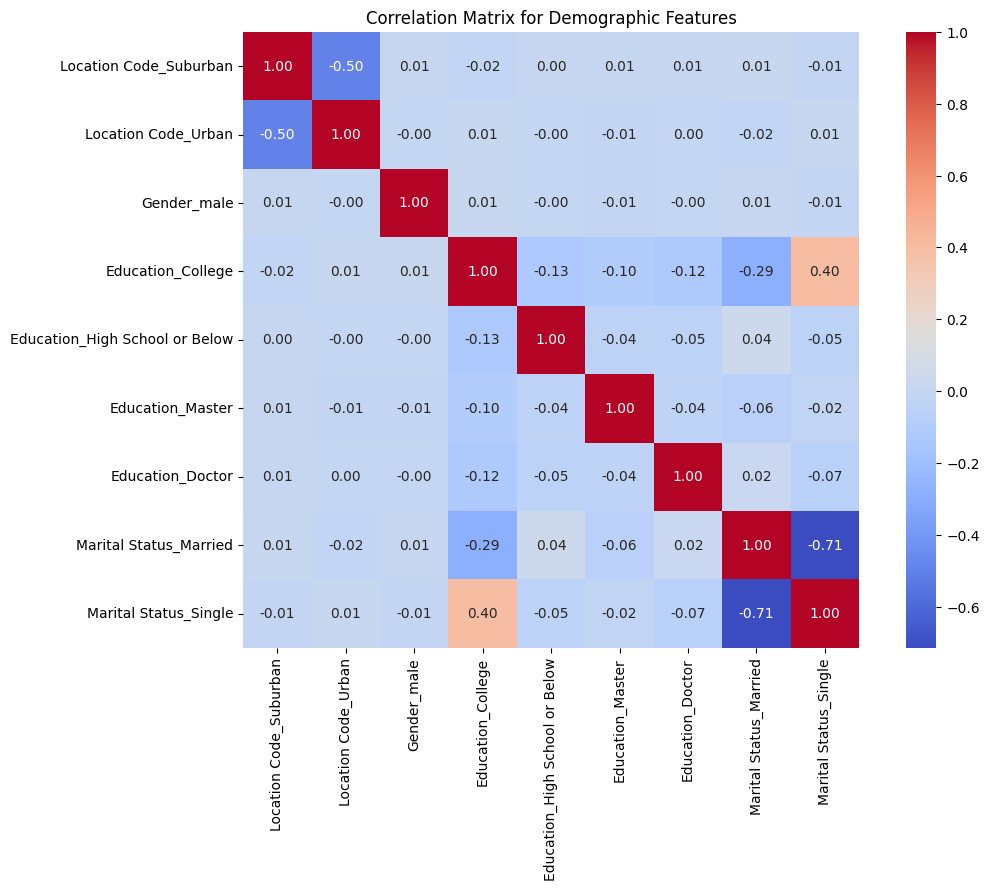

Pairs with correlation > 0.8 or < -0.8:
Series([], dtype: float64)


In [82]:
# Check for correlation inside the value based features
plt.figure(figsize=(12, 8))
correlation_matrix = df_demographic.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix for Demographic Features")
plt.show()

threshold = 0.8
unstacked = correlation_matrix.unstack()
high_corr = unstacked[(unstacked.abs() > threshold) & (unstacked != 1.0)].drop_duplicates()

print(f"Pairs with correlation > {threshold} or < -{threshold}:")
print(high_corr)

We will do K-Means++ Clustering and compare it with Hierarchical Clustering

In [ ]:
# --- Comprehensive Clustering Evaluation with All Metrics ---

def evaluate_clustering_methods(data, feats, min_k=2, max_k=11):
    """
    Evaluates multiple clustering methods and calculates:
    - R2 Score
    - Davies-Bouldin Index (DBI)
    - Silhouette Score
    - Inertia (for KMeans-based methods)
    
    Returns a dictionary with DataFrames for each method.
    """
    
    X = data.values if isinstance(data, pd.DataFrame) else data
    
    # Calculate Total Sum of Squares (SST) once for R2 calculation
    centroid = X.mean(axis=0)
    sst = np.sum((X - centroid) ** 2)
    
    # Initialize results dictionary
    results_by_method = {}
    
    # --- K-MEANS ---
    print("Evaluating K-Means...")
    kmeans_results = []
    kmeans_clusterer = KMeans(init='k-means++', n_init=20, random_state=42)
    
    for k in range(min_k, max_k):
        kmeans = clone(kmeans_clusterer).set_params(n_clusters=k)
        labels = kmeans.fit_predict(X)
        
        # Calculate metrics
        ssw = kmeans.inertia_
        r2 = 1 - (ssw / sst)
        dbi = davies_bouldin_score(X, labels)
        sil = silhouette_score(X, labels)
        
        kmeans_results.append({
            'K': k,
            'R2_Score': r2,
            'Davies_Bouldin': dbi,
            'Silhouette': sil,
            'Inertia': ssw
        })
    
    df_kmeans = pd.DataFrame(kmeans_results)
    df_kmeans.loc[:, 'R2_Pct_Change'] = df_kmeans['R2_Score'].pct_change() * 100
    df_kmeans.loc[:, 'DBI_Pct_Change'] = df_kmeans['Davies_Bouldin'].pct_change() * 100
    df_kmeans.loc[:, 'Sil_Pct_Change'] = df_kmeans['Silhouette'].pct_change() * 100
    df_kmeans.loc[:, 'Inertia_Pct_Change'] = df_kmeans['Inertia'].pct_change() * 100
    
    results_by_method['kmeans'] = df_kmeans
    
    # --- HIERARCHICAL CLUSTERING (Various Linkages) ---
    hierarchical_clusterer = AgglomerativeClustering(metric='euclidean')
    
    for linkage_type in ['complete', 'average', 'single', 'ward']:
        print(f"Evaluating Hierarchical Clustering ({linkage_type})...")
        hc_results = []
        
        for k in range(min_k, max_k):
            hc = clone(hierarchical_clusterer).set_params(n_clusters=k, linkage=linkage_type)
            labels = hc.fit_predict(X)
            
            # Calculate metrics
            dbi = davies_bouldin_score(X, labels)
            sil = silhouette_score(X, labels)
            
            # Calculate R2 for hierarchical clustering
            df_concat = pd.concat([data, pd.Series(labels, name='labels', index=data.index)], axis=1)
            r2 = get_rsq(df_concat, feats, 'labels')
            
            # Hierarchical clustering doesn't have inertia, so we'll use None
            hc_results.append({
                'K': k,
                'R2_Score': r2,
                'Davies_Bouldin': dbi,
                'Silhouette': sil,
                'Inertia': np.nan  # Not applicable for hierarchical clustering
            })
        
        df_hc = pd.DataFrame(hc_results)
        df_hc.loc[:, 'R2_Pct_Change'] = df_hc['R2_Score'].pct_change() * 100
        df_hc.loc[:, 'DBI_Pct_Change'] = df_hc['Davies_Bouldin'].pct_change() * 100
        df_hc.loc[:, 'Sil_Pct_Change'] = df_hc['Silhouette'].pct_change() * 100
        df_hc.loc[:, 'Inertia_Pct_Change'] = df_hc['Inertia'].pct_change() * 100
        
        results_by_method[linkage_type] = df_hc
    
    return results_by_method

# --- EXECUTION ---
print("Starting comprehensive clustering evaluation...\n")
clustering_results_demographic = evaluate_clustering_methods(df_demographic, demographic_features, min_k=2, max_k=11)

# --- DISPLAY RESULTS FOR EACH METHOD ---
for method_name, df_method in clustering_results_demographic.items():
    print(f"\n{'='*80}")
    print(f"METHOD: {method_name.upper()}")
    print(f"{'='*80}")
    display(df_method.round(4))
    
    # Highlight best K for each metric
    print(f"\nBest configurations for {method_name}:")
    print(f"  - Highest R2: K={df_method.loc[df_method['R2_Score'].idxmax(), 'K']:.0f}")
    print(f"  - Lowest Davies-Bouldin: K={df_method.loc[df_method['Davies_Bouldin'].idxmin(), 'K']:.0f}")
    print(f"  - Highest Silhouette: K={df_method.loc[df_method['Silhouette'].idxmax(), 'K']:.0f}")

In [ ]:
# --- Visualization: 4 Subplots (One per Metric, All Methods) ---

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Prepare data for plotting
metrics_data = {
    'R2_Score': axes[0, 0],
    'Davies_Bouldin': axes[0, 1],
    'Silhouette': axes[1, 0],
    'Inertia': axes[1, 1]
}

metric_labels = {
    'R2_Score': 'R² Score (Higher is Better)',
    'Davies_Bouldin': 'Davies-Bouldin Index (Lower is Better)',
    'Silhouette': 'Silhouette Score (Higher is Better)',
    'Inertia': 'Inertia (Lower is Better)'
}

# Plot each metric
for metric_name, ax in metrics_data.items():
    for method_name, df_method in clustering_results_demographic.items():
        ax.plot(df_method['K'], df_method[metric_name], marker='o', label=method_name, linewidth=2)
    
    ax.set_title(metric_labels[metric_name], fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of Clusters (K)', fontsize=12)
    ax.set_ylabel(metric_name.replace('_', ' '), fontsize=12)
    ax.legend(title='Clustering Methods', title_fontsize=11, fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(2, 11))

    # Add horizontal threshold line for R² Score
    if metric_name == 'R2_Score':
        ax.axhline(y=0.5, color='r', linestyle='--', label='Threshold = 0.5')
        ax.legend(title='Clustering Methods', title_fontsize=11, fontsize=10)

plt.tight_layout()
plt.show()


Based on the evaluation metrics and visualizations, we decided to proceed with K-Means clustering using K = 5. This choice offers a balanced trade-off between cluster cohesion and separation.

In [86]:
# 1. Perform final clustering
k_best_demo = 5

kmeans_demo = KMeans(n_clusters=k_best_demo, init='k-means++', n_init=20, random_state=42)

demo_labels = kmeans_demo.fit_predict(df_demographic)

customers['demographic_cluster'] = demo_labels

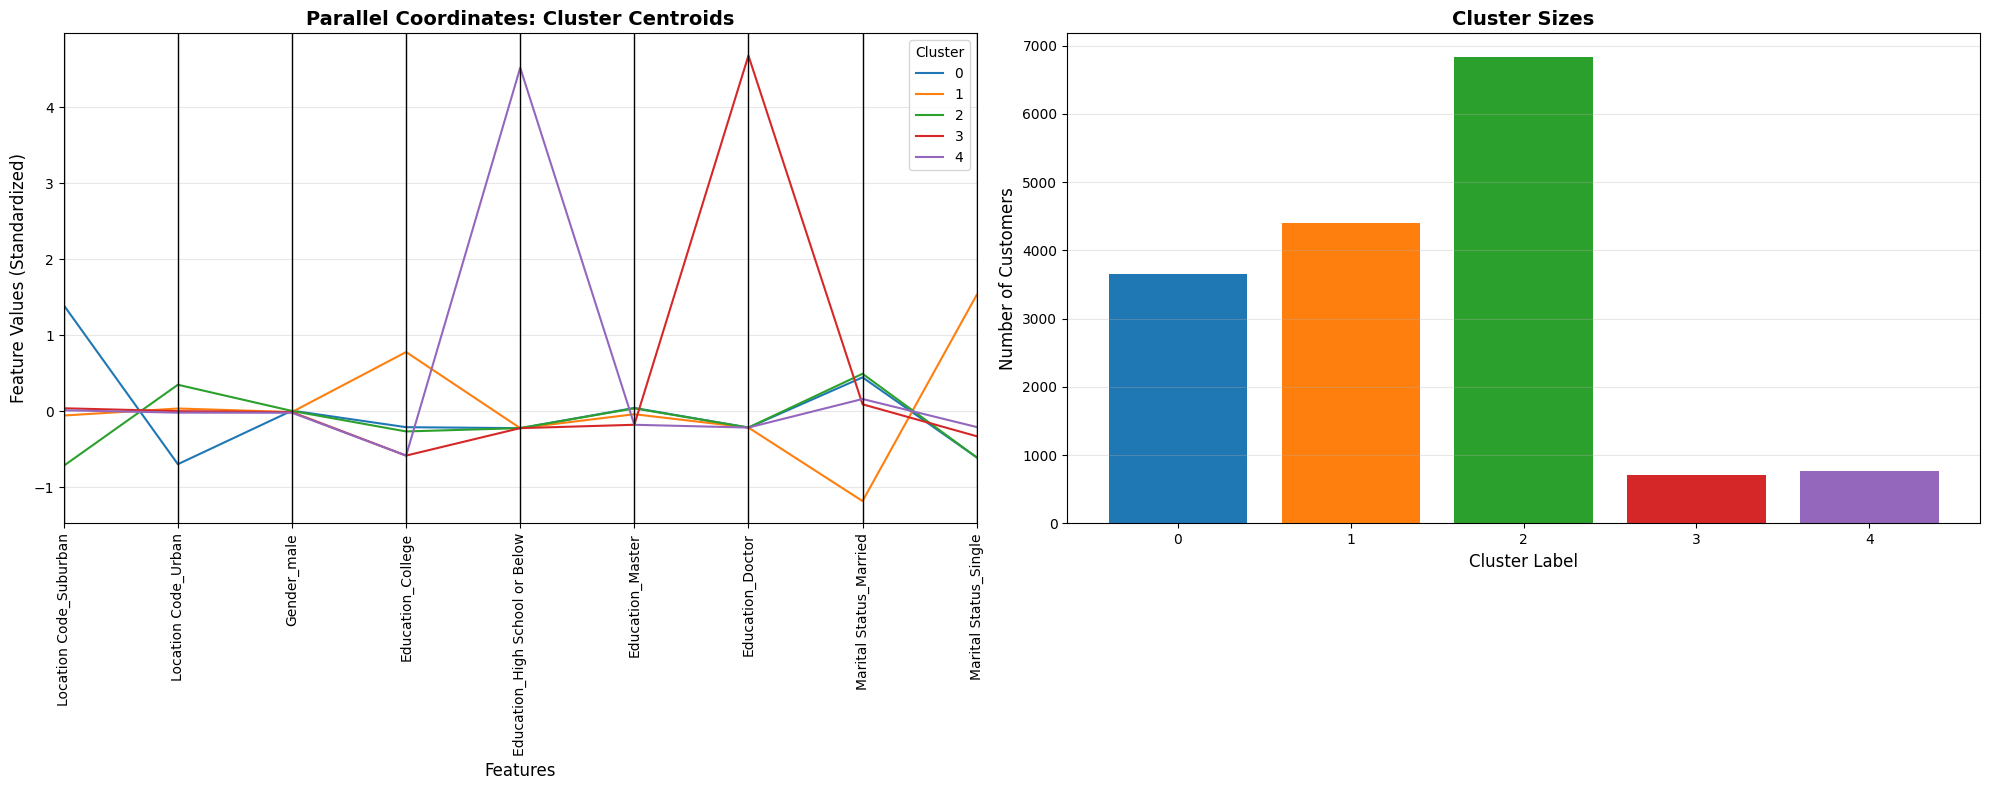

In [87]:
# Demographic cluster profiling
df_profile_demo = df_demographic.copy()
df_profile_demo['cluster'] = demo_labels

# 3. Calculate Centroids (Average values per cluster)
df_centroids_demo = df_profile_demo.groupby('cluster')[demographic_features].mean()

# --- Visualization 1: Parallel Coordinates & Cluster Sizes ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# LEFT PLOT: Parallel coordinates
# We use reset_index() so that 'cluster' is a column for coloring
pd.plotting.parallel_coordinates(
    df_centroids_demo.reset_index(),
    'cluster',
    color=sns.color_palette('tab10', n_colors=k_best_demo),
    ax=ax1
)
ax1.set_title('Parallel Coordinates: Cluster Centroids', fontsize=14, fontweight='bold')
ax1.set_ylabel('Feature Values (Standardized)', fontsize=12)
ax1.set_xlabel('Features', fontsize=12)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=90) # Rotate labels for readability
ax1.grid(True, alpha=0.3)
ax1.legend(title='Cluster', loc='best')

# RIGHT PLOT: Cluster sizes
cluster_sizes = df_profile_demo['cluster'].value_counts().sort_index()
colors = sns.color_palette('tab10', n_colors=k_best_demo)

ax2.bar(cluster_sizes.index.astype(str), cluster_sizes.values, color=colors)
ax2.set_xlabel('Cluster Label', fontsize=12)
ax2.set_ylabel('Number of Customers', fontsize=12)
ax2.set_title('Cluster Sizes', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

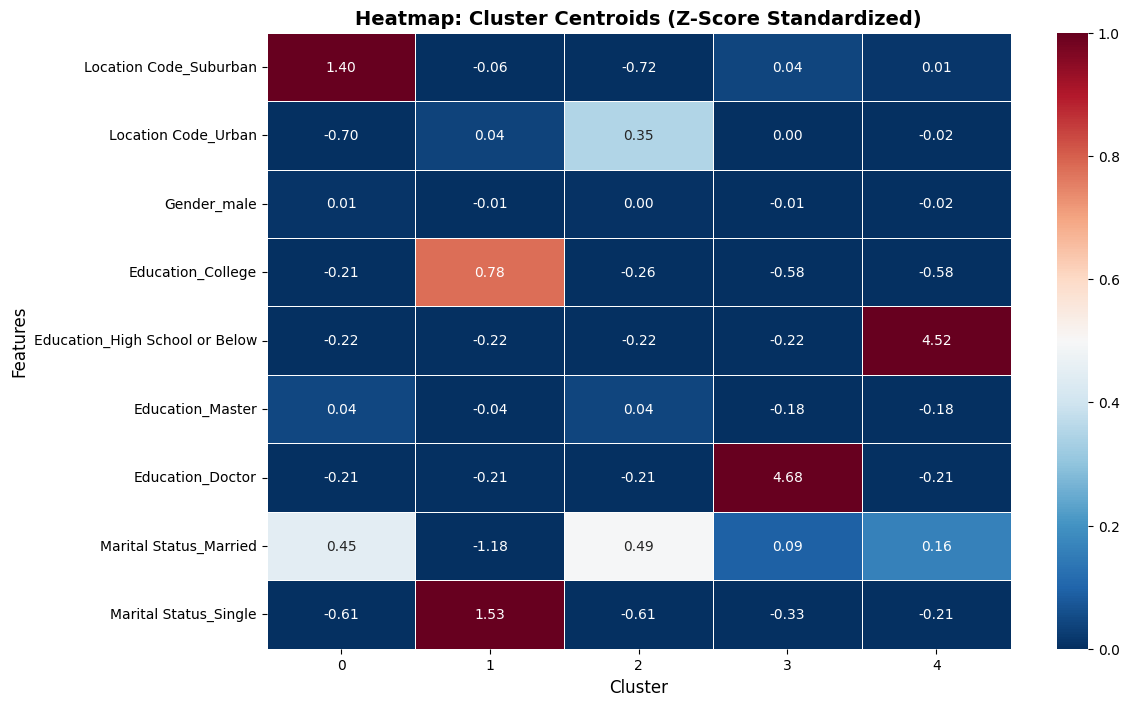

In [88]:
# --- Visualization 2: Heatmap of Centroids ---
plt.figure(figsize=(12, 8))

# Prepare data: Features as rows
df_plot = df_centroids_demo.T

# Transpose (T) so that features are on the Y-axis
sns.heatmap(
    df_plot, 
    cmap='RdBu_r',  # Red-Blue colormap (good for deviations from the mean)
    center=0.5,     # Centered at 0.5 for standardized data
    annot=True,     # Show values
    fmt='.2f',      # 2 decimal places
    linewidths=.5,
    vmin=0,         # Minimum at 0
    vmax=1          # Maximum at 1
)

plt.title('Heatmap: Cluster Centroids (Z-Score Standardized)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

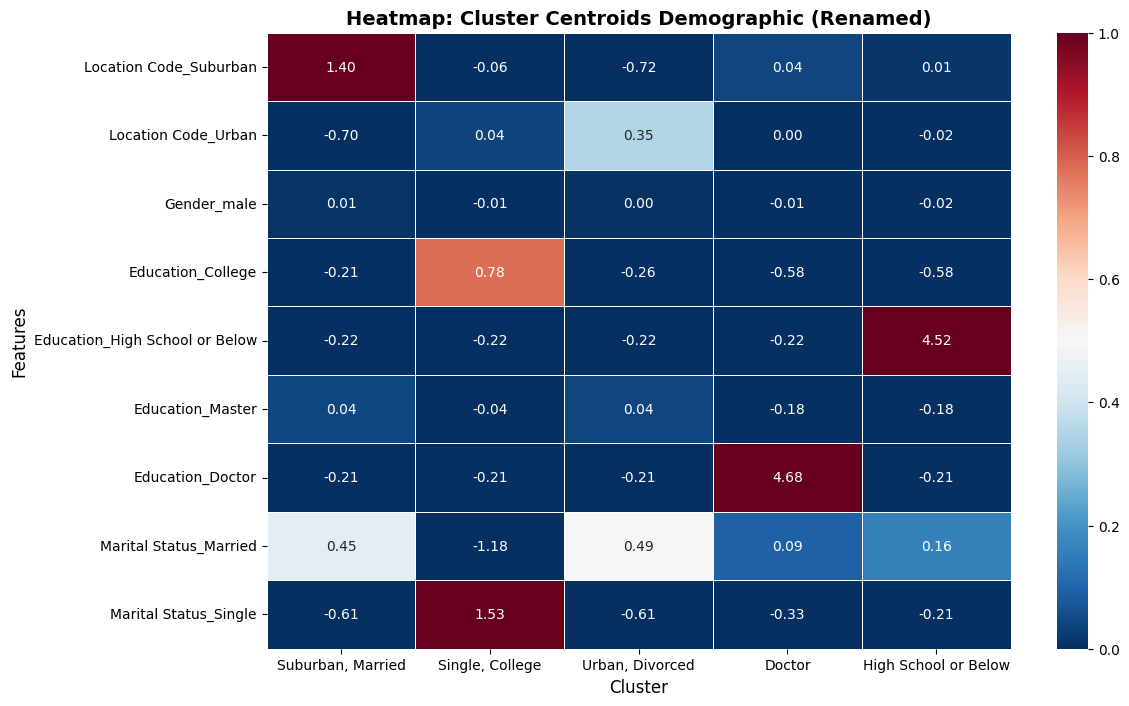

In [89]:
# --- Visualization 2: Heatmap of Centroids (Renamed) ---
plt.figure(figsize=(12, 8))

# Rename clusters
df_centroids_demo_renamed = df_centroids_demo.rename(index={
    0: 'Suburban, Married',
    1: 'Single, College' ,
    2: 'Urban, Divorced',
    3: 'Doctor',
    4: 'High School or Below'
})

# Prepare data: Features as rows
df_plot = df_centroids_demo_renamed.T

# Transpose (T) so that features are on the Y-axis
sns.heatmap(
    df_plot, 
    cmap='RdBu_r',  # Red-Blue colormap (good for deviations from the mean)
    center=0.5,     # Centered at 0.5 for standardized data
    annot=True,     # Show values
    fmt='.2f',      # 2 decimal places
    linewidths=.5,
    vmin=0,         # Minimum at 0
    vmax=1          # Maximum at 1
)

plt.title('Heatmap: Cluster Centroids Demographic (Renamed)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

Number of customers in each cluster:
Cluster Suburban, Married: 3654 customers
Cluster Single, College: 4404 customers
Cluster Urban, Divorced: 6838 customers
Cluster Doctor: 715 customers
Cluster High School or Below: 764 customers


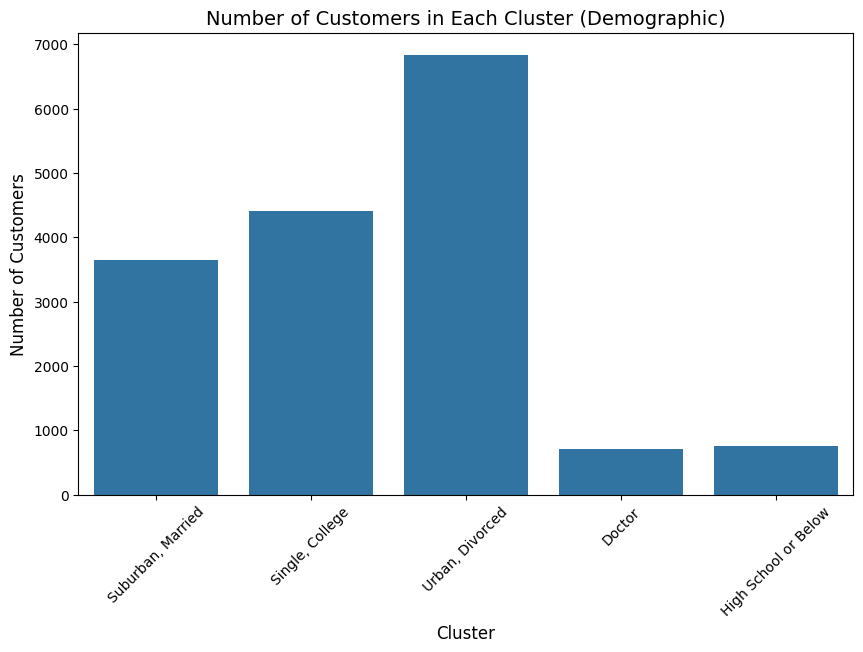

In [99]:
# Define cluster names
demo_cluster_names = {
    0: 'Suburban, Married',
    1: 'Single, College' ,
    2: 'Urban, Divorced',
    3: 'Doctor',
    4: 'High School or Below'
}

# Count the number of customers in each cluster and display the result and plot it
cluster_counts = df_profile_demo['cluster'].value_counts().sort_index()

# Rename the index
cluster_counts.index = cluster_counts.index.map(demo_cluster_names)

print("Number of customers in each cluster:")
for cluster_label, count in cluster_counts.items():
    print(f"Cluster {cluster_label}: {count} customers")

plt.figure(figsize=(10, 6))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values)
plt.title('Number of Customers in Each Cluster (Demographic)', fontsize=14)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45)
plt.show()

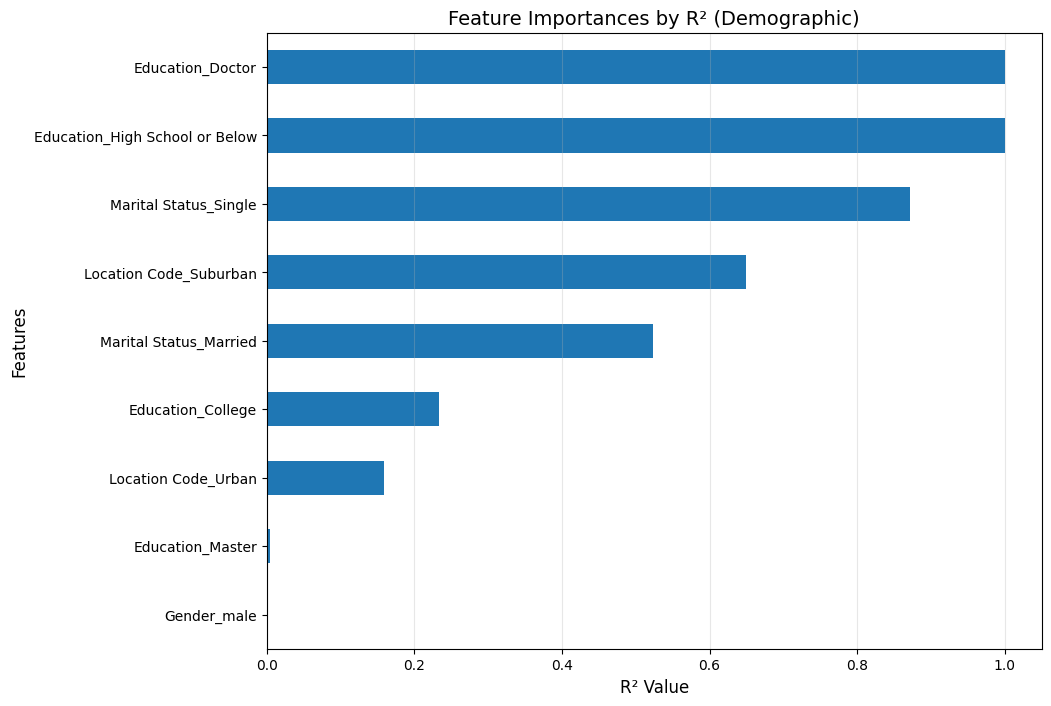

In [100]:
# Since 'r2_variables' is not defined, we calculate R2 for each feature individually
# using the existing 'get_rsq' function.
r2_data = {}
for feature in demographic_features:
    # get_rsq expects a list of features, hence [feature]
    r2_data[feature] = get_rsq(df_profile_demo, [feature], 'cluster')

r2_feats = pd.Series(r2_data)

# Plotting
r2_feats.sort_values().plot.barh(figsize=(10, 8))
plt.title("Feature Importances by R² (Demographic)", fontsize=14)
plt.xlabel("R² Value", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.show()

# 3 Merging Clusters

Cross-Tabulation Segmentation

For Interpretability and Business INsights we decided for this approach. We tried different methods approaches which are more complex, but this simple one made the best results. With this one we are able to seperate the clusters and make analytical decisions. We can classify our different type of customers better than with complex ones.

In [92]:
customers.head()

,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,...,Province or State_Nova Scotia,Province or State_Ontario,Province or State_Prince Edward Island,Province or State_Quebec,Province or State_Saskatchewan,Province or State_Yukon,Location Code_Suburban,Location Code_Urban,valuebased_cluster,demographic_cluster
Loyalty#,,,,,,,,,,,,,,,,,,,,,
480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,-1.064828,0.559917,M2Z 4K1,female,...,-0.182176,1.448178,-0.063615,-0.493981,-0.156403,-0.080718,-0.716227,1.437326,0,2
549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,1.926313,-0.973351,T3G 6Y6,male,...,-0.182176,-0.690523,-0.063615,-0.493981,-0.156403,-0.080718,-0.716227,-0.695737,3,1
429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,0.637565,-1.406246,V6E 3D9,male,...,-0.182176,-0.690523,-0.063615,-0.493981,-0.156403,-0.080718,-0.716227,1.437326,3,1
608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,-1.064828,0.559917,P1W 1K4,male,...,-0.182176,1.448178,-0.063615,-0.493981,-0.156403,-0.080718,1.396205,-0.695737,3,1
530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,-0.527905,0.724889,J8Y 3Z5,male,...,-0.182176,-0.690523,-0.063615,2.024369,-0.156403,-0.080718,1.396205,-0.695737,0,0


Cross-Tabulation (Value-Based x Demographic):


demographic_cluster,"Suburban, Married","Single, College","Urban, Divorced",Doctor,High School or Below
valuebased_cluster,,,,,
High Income,1293,725,2541,0,0
Low Points and Costs,1061,1223,1962,201,231
High CLV,244,290,482,45,56
Low Income,1056,2166,1853,469,477


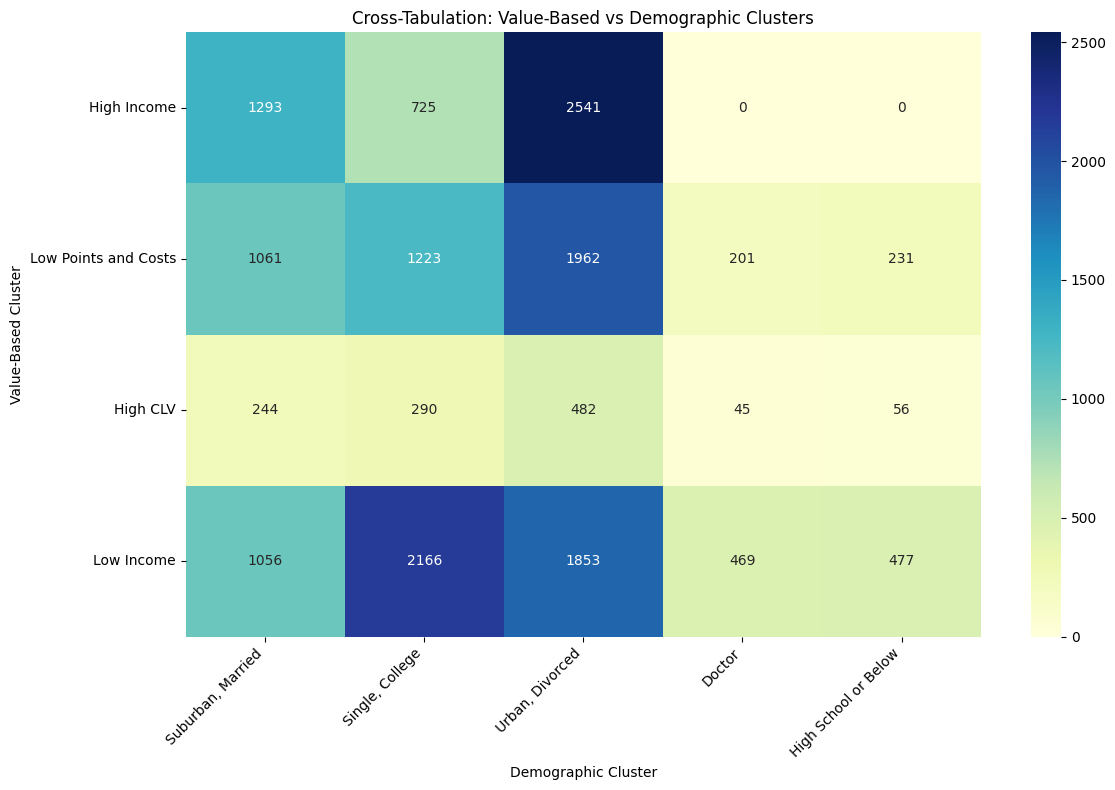

In [93]:
# Define mappings for cluster names from previous visuals
value_cluster_names = {
    0: 'High Income',
    1: 'Low Points and Costs',
    2: 'High CLV',
    3: 'Low Income'
}

demo_cluster_names = {
    0: 'Suburban, Married',
    1: 'Single, College' ,
    2: 'Urban, Divorced',
    3: 'Doctor',
    4: 'High School or Below'
}


# Create Cross-Tabulation
cross_tab = pd.crosstab(customers['valuebased_cluster'], customers['demographic_cluster'])

# Rename index and columns
cross_tab.rename(index=value_cluster_names, columns=demo_cluster_names, inplace=True)

print("Cross-Tabulation (Value-Based x Demographic):")
display(cross_tab)

# Heatmap Visualization of Cross-Tabulation
plt.figure(figsize=(12, 8))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Cross-Tabulation: Value-Based vs Demographic Clusters')
plt.xlabel('Demographic Cluster')
plt.ylabel('Value-Based Cluster')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 3.1 Merging Clusters
We will now create a new cluster variable that combines both perspectives (e.g., "V0_D1").

In [94]:
# Create new variable 'merged_cluster'
customers['merged_cluster'] = (
    'V' + customers['valuebased_cluster'].astype(str) + 
    '_D' + customers['demographic_cluster'].astype(str)
)

# Number of unique combined clusters
n_merged = customers['merged_cluster'].nunique()
print(f"Number of merged clusters: {n_merged}")

# Show the most frequent combinations
print("\nMost frequent cluster combinations:")
print(customers['merged_cluster'].value_counts().head(10))

Number of merged clusters: 18

Most frequent cluster combinations:
merged_cluster
V0_D2    2541
V3_D1    2166
V1_D2    1962
V3_D2    1853
V0_D0    1293
V1_D1    1223
V1_D0    1061
V3_D0    1056
V0_D1     725
V2_D2     482
Name: count, dtype: int64


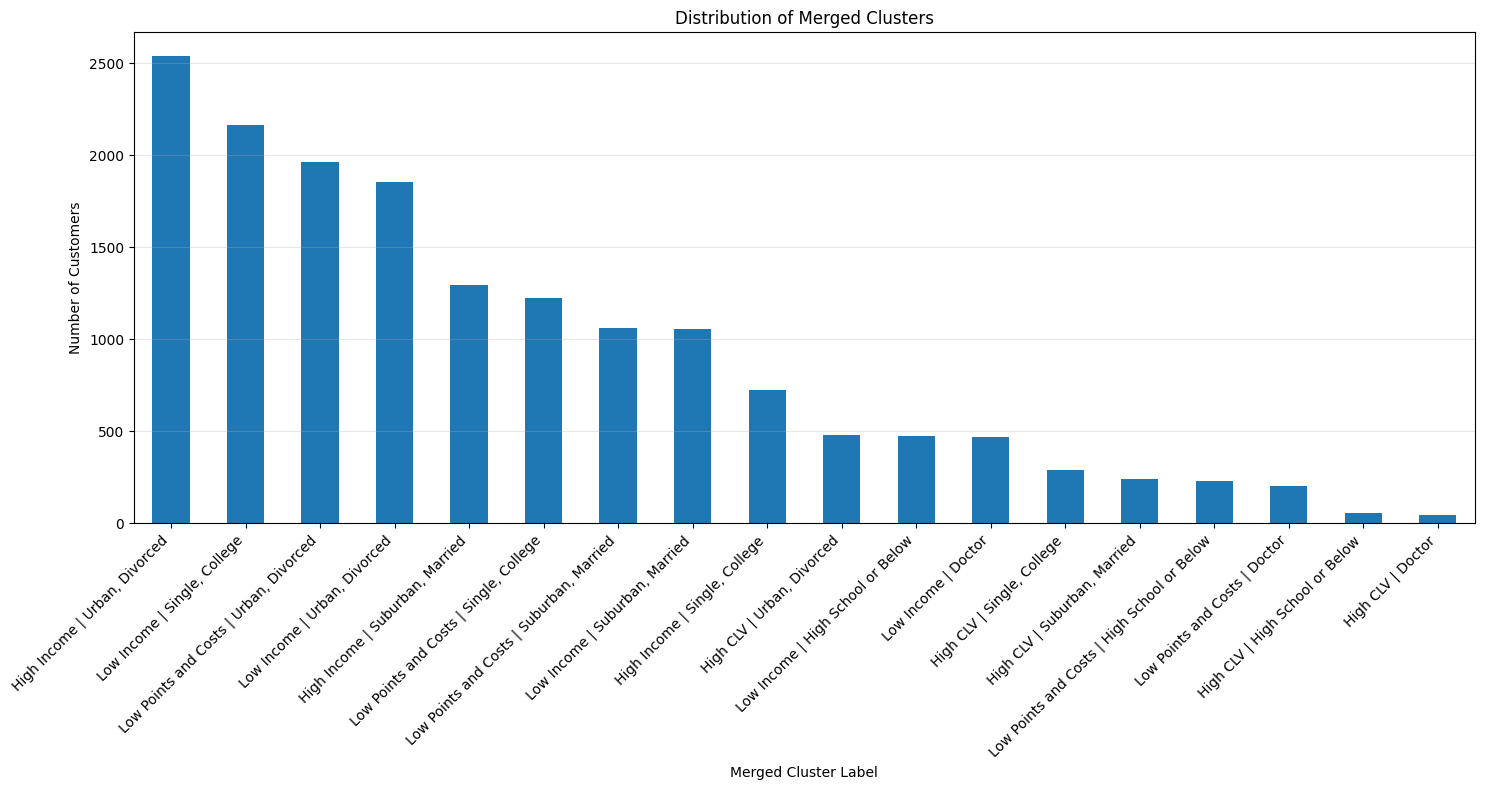

In [104]:
# Visualize distribution of merged clusters with descriptive names

# Define mappings
value_cluster_names = {
    0: 'High Income',
    1: 'Low Points and Costs',
    2: 'High CLV',
    3: 'Low Income'
}
demo_cluster_names = {
    0: 'Suburban, Married',
    1: 'Single, College' ,
    2: 'Urban, Divorced',
    3: 'Doctor',
    4: 'High School or Below'
}

# Create descriptive labels
customers['merged_cluster_label'] = (
    customers['valuebased_cluster'].map(value_cluster_names) + 
    ' | ' + 
    customers['demographic_cluster'].map(demo_cluster_names)
)

plt.figure(figsize=(15, 8))
customers['merged_cluster_label'].value_counts().plot(kind='bar')
plt.title('Distribution of Merged Clusters')
plt.xlabel('Merged Cluster Label')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3.2 Interpretation of Merged Clusters


Select the Clusters, which are most important for the interpretation. 

- Low Income Customers have the least potential for sales strategy. We exclude them.
- Customers with the label 'High school or Below' and Doctors have a low sample size. 

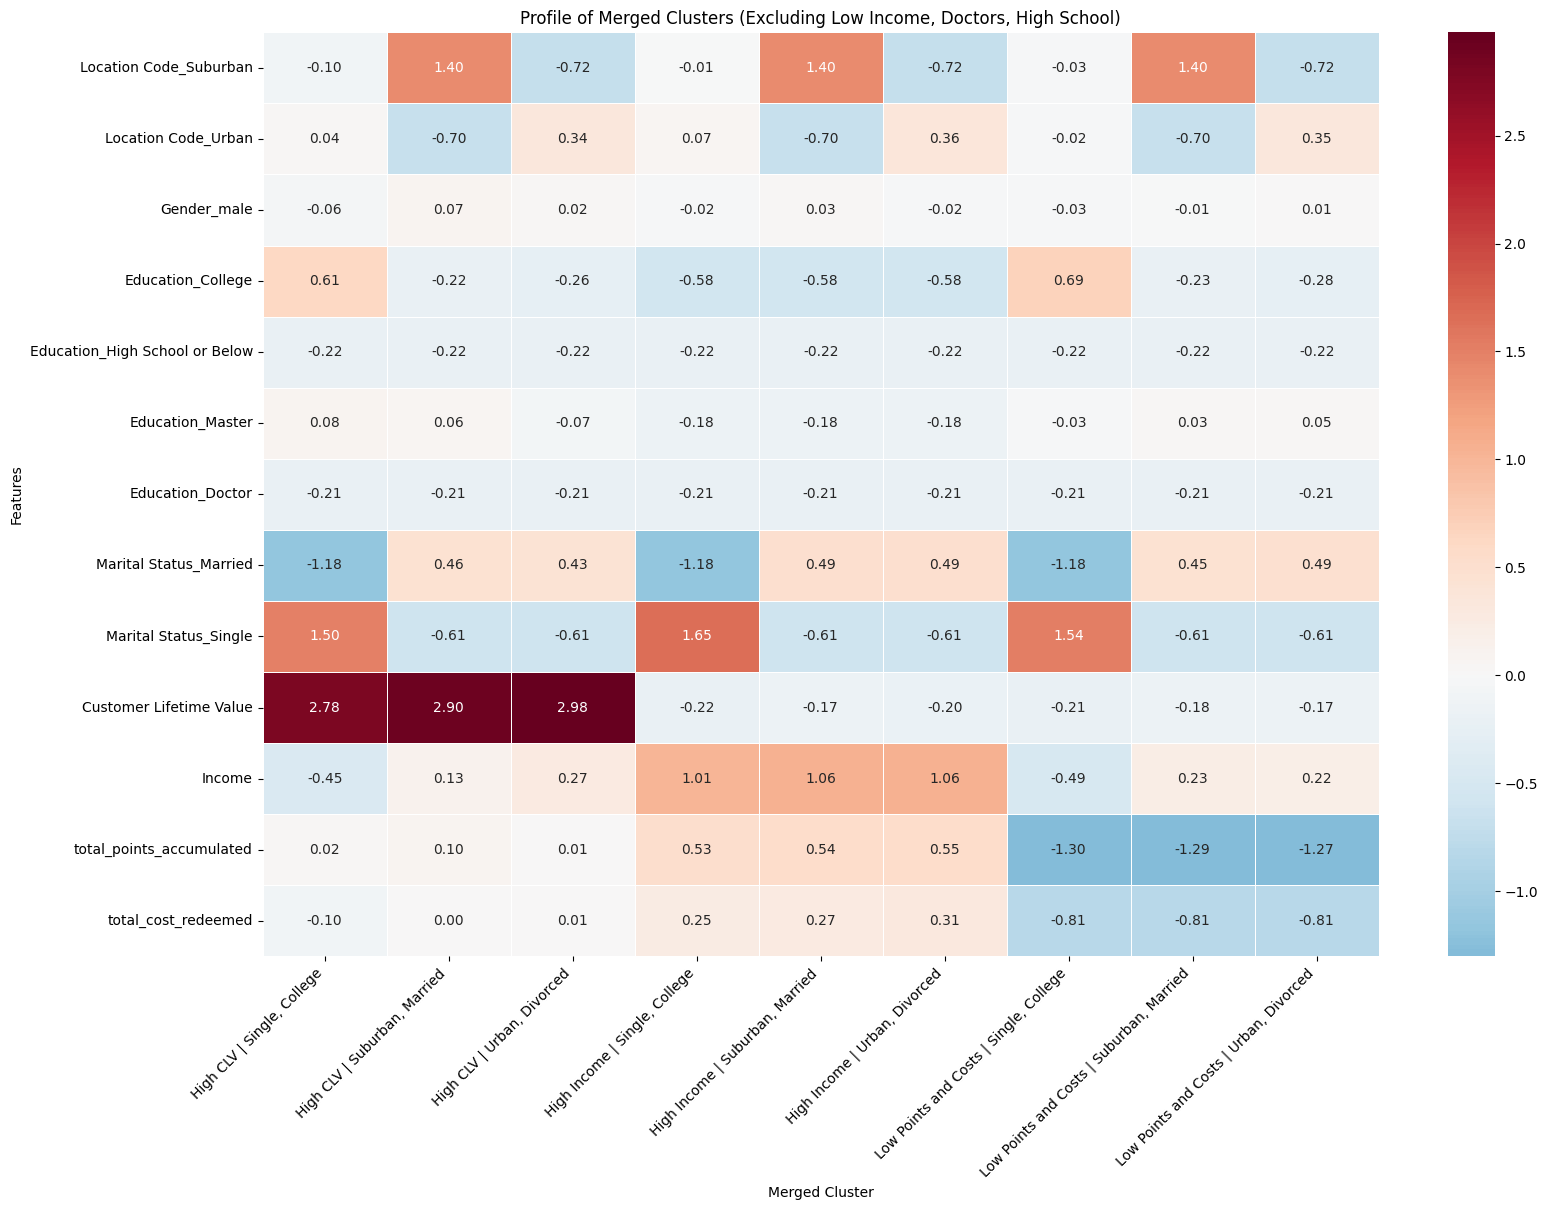

In [101]:
# Profiling of Merged Clusters (Excluding Low Income, Doctors, and High School or Below)
# We exclude Value Cluster 3 (Low Income)
# We also exclude Demographic Clusters 3 (Doctor) and 4 (High School or Below) due to low sample size
filtered_customers = customers[
    (customers['valuebased_cluster'] != 3) & 
    (~customers['demographic_cluster'].isin([3, 4]))
].copy()

# Create descriptive labels for the merged clusters
# Format: "Value Name | Demo Name"
filtered_customers['merged_cluster_label'] = (
    filtered_customers['valuebased_cluster'].map(value_cluster_names) + 
    ' | ' + 
    filtered_customers['demographic_cluster'].map(demo_cluster_names)
)

# Calculate means for the remaining merged clusters using the new labels
df_merged_profile = filtered_customers.groupby('merged_cluster_label')[metric_features].mean()

# Z-Score Standardization for the Heatmap (to better see differences)
# We standardize against the global population statistics to see deviations from the overall average
df_merged_profile_std = (df_merged_profile - customers[metric_features].mean()) / customers[metric_features].std()

# Heatmap of the Profile
plt.figure(figsize=(18, 12))
sns.heatmap(
    df_merged_profile_std.T, 
    cmap='RdBu_r', 
    center=0, 
    annot=True, 
    fmt='.2f',
    linewidths=.5
)
plt.title('Profile of Merged Clusters (Excluding Low Income, Doctors, High School)')
plt.xlabel('Merged Cluster')
plt.ylabel('Features')
plt.xticks(rotation=45, ha='right') # Rotate labels for readability
plt.show()

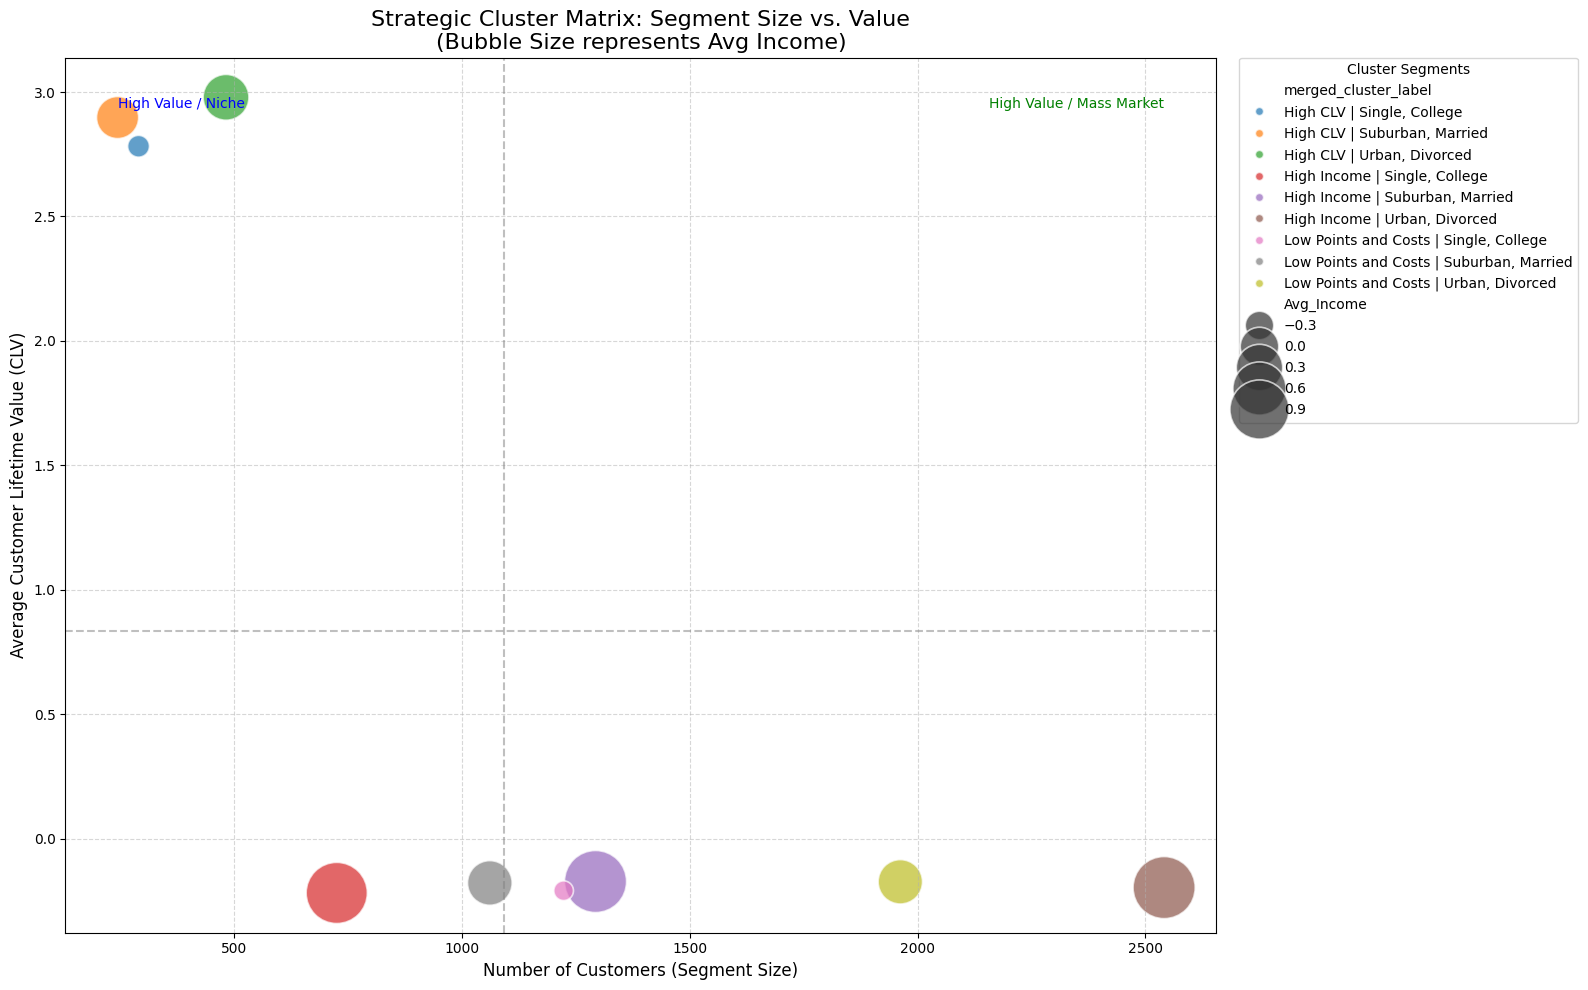

In [102]:
# --- Visualization 4: Strategic Value Matrix (Bubble Chart) ---
# X-Axis: Segment Size (Reach)
# Y-Axis: Average CLV (Value)
# Bubble Size: Average Income (Purchasing Power)

# 1. Prepare the summary data
# We use reset_index() so 'Loyalty#' becomes a column we can count
strategic_summary = filtered_customers.reset_index().groupby('merged_cluster_label').agg({
    'Customer Lifetime Value': 'mean',
    'Loyalty#': 'count',
    'Income': 'mean'
}).reset_index()

strategic_summary.rename(columns={
    'Loyalty#': 'Count', 
    'Customer Lifetime Value': 'Avg_CLV', 
    'Income': 'Avg_Income'
}, inplace=True)

# 2. Plot
plt.figure(figsize=(16, 10)) # Increased width to accommodate legend
scatter = sns.scatterplot(
    data=strategic_summary, 
    x='Count', 
    y='Avg_CLV', 
    size='Avg_Income', 
    sizes=(200, 2000), # Range of bubble sizes
    hue='merged_cluster_label', 
    palette='tab10',
    alpha=0.7
)

# 3. Legend configuration (Moved outside)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title='Cluster Segments')

plt.title('Strategic Cluster Matrix: Segment Size vs. Value\n(Bubble Size represents Avg Income)', fontsize=16)
plt.xlabel('Number of Customers (Segment Size)', fontsize=12)
plt.ylabel('Average Customer Lifetime Value (CLV)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Add quadrants (optional, based on mean values)
plt.axvline(x=strategic_summary['Count'].mean(), color='grey', linestyle='--', alpha=0.5)
plt.axhline(y=strategic_summary['Avg_CLV'].mean(), color='grey', linestyle='--', alpha=0.5)

plt.text(strategic_summary['Count'].max(), strategic_summary['Avg_CLV'].max(), 'High Value / Mass Market', ha='right', va='top', color='green', fontsize=10)
plt.text(strategic_summary['Count'].min(), strategic_summary['Avg_CLV'].max(), 'High Value / Niche', ha='left', va='top', color='blue', fontsize=10)

plt.tight_layout() # Adjust layout to fit legend
plt.show()

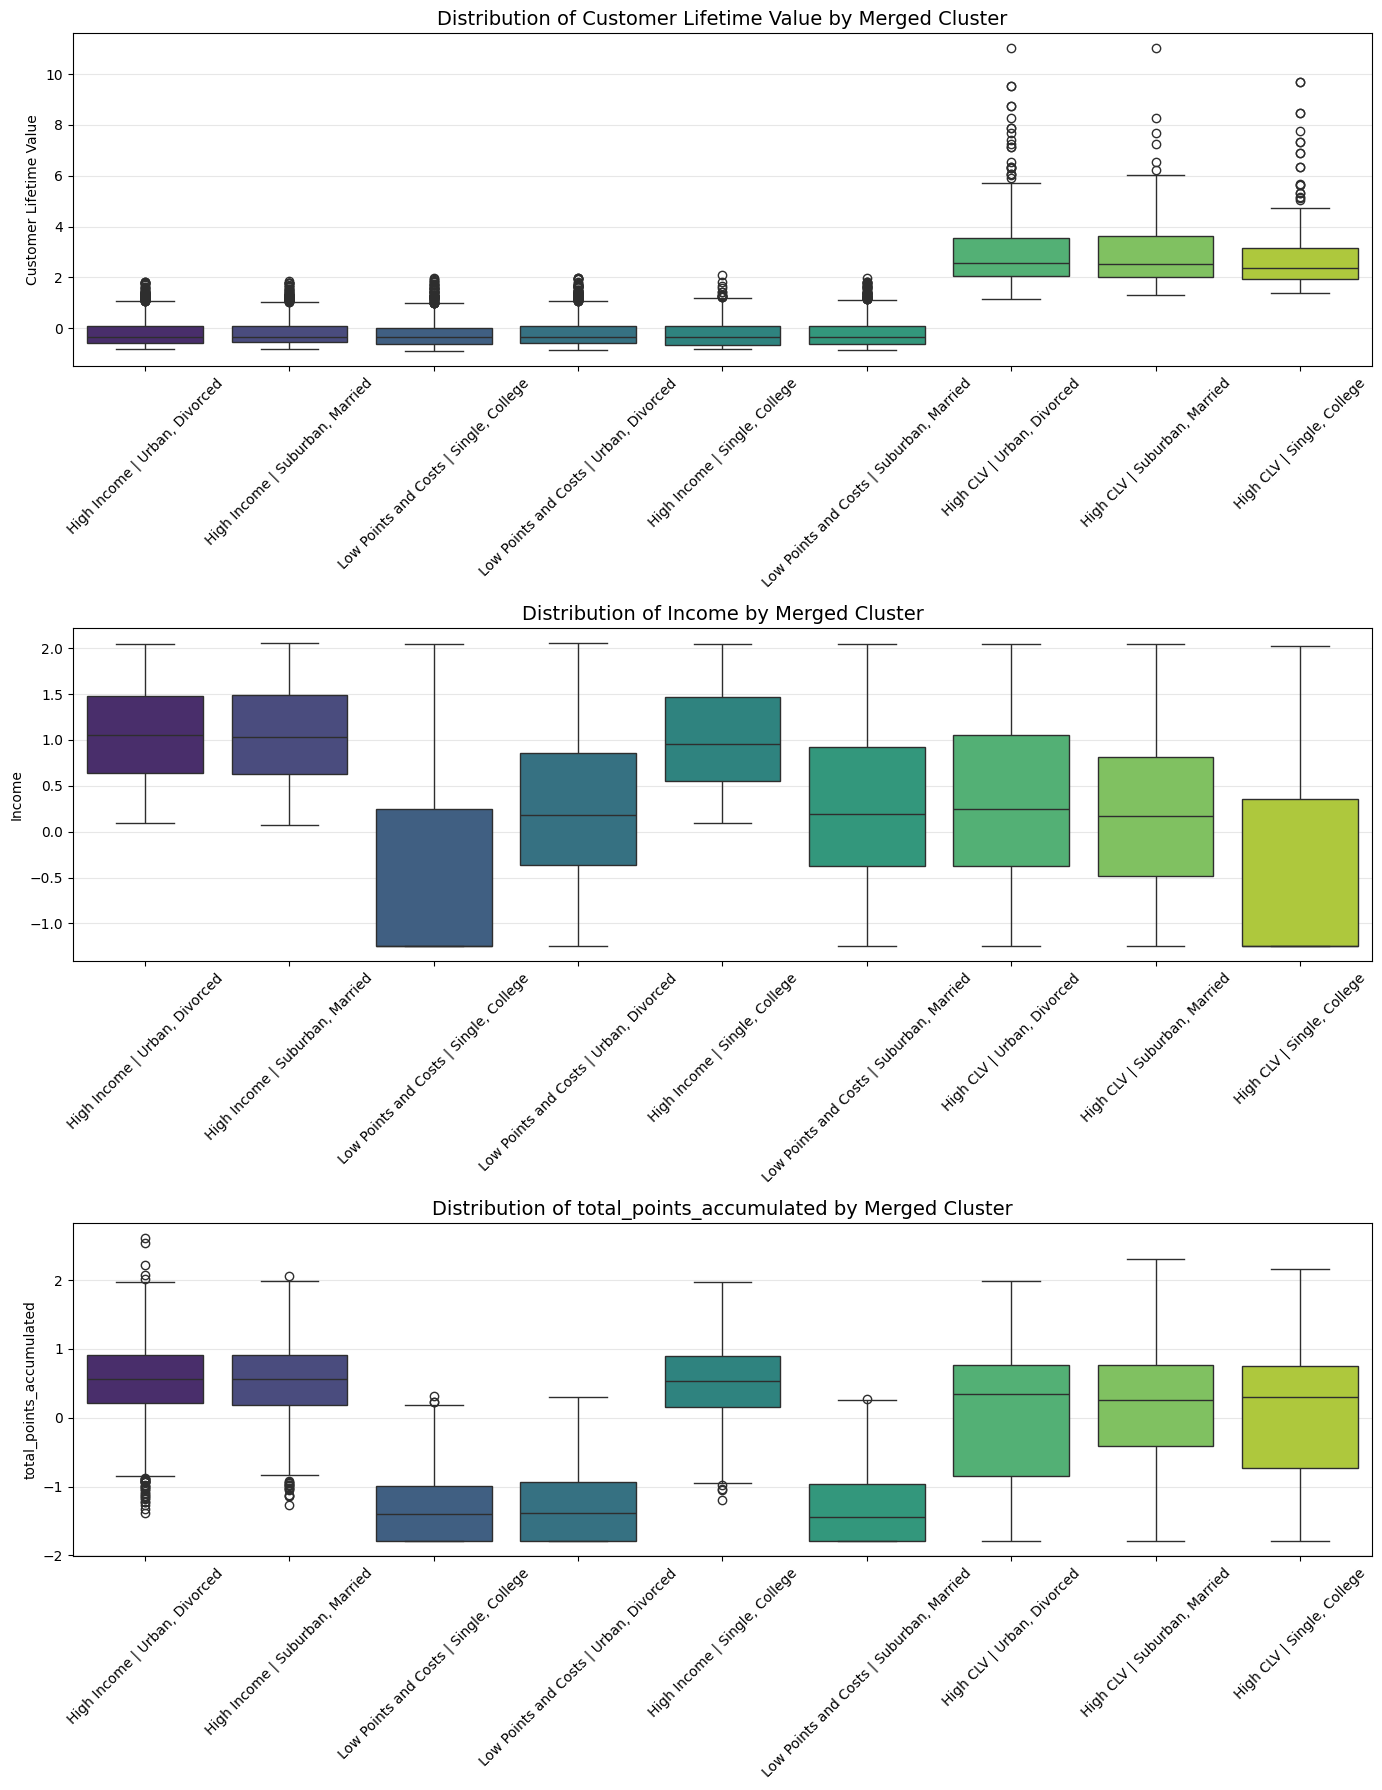

In [103]:
# --- Visualization 3: Distribution of Key Metrics (Boxplots) ---
# This helps us see the spread and outliers within each segment

key_features = ['Customer Lifetime Value', 'Income', 'total_points_accumulated']

fig, axes = plt.subplots(len(key_features), 1, figsize=(14, 6 * len(key_features)))

for i, feature in enumerate(key_features):
    sns.boxplot(
        data=filtered_customers, 
        x='merged_cluster_label', 
        y=feature, 
        ax=axes[i],
        palette='viridis'
    )
    axes[i].set_title(f'Distribution of {feature} by Merged Cluster', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### 3.3 Deep Dive Analysis & Strategic Implications

To better understand the heterogeneity within our merged clusters and to derive strategic priorities, we add two layers of analysis:

1.  **Distribution Analysis (Boxplots):** While means (in the heatmap) are useful, they hide the spread of the data. Boxplots help us check if the clusters are distinct and compact, or if there are significant overlaps and outliers.
2.  **Strategic Value Matrix:** A scatter plot comparing **Segment Size** vs. **Value (CLV)**. This is a classic consultancy tool to identify "Niche High-Value" segments (Gold Mines) vs. "Mass Market" segments.
